KAPREKAR SILVER BULLET: CYCLES IN FINITE ALPHABETS

Running Silver Bullet Simulation...
3 Digits: Converged to cycle of length 1
4 Digits: Converged to cycle of length 1
5 Digits: Converged to cycle of length 4
6 Digits: Converged to cycle of length 7
7 Digits: Converged to cycle of length 8
8 Digits: Converged to cycle of length 7

✓ Saved: kaprekar_silver_bullet.png


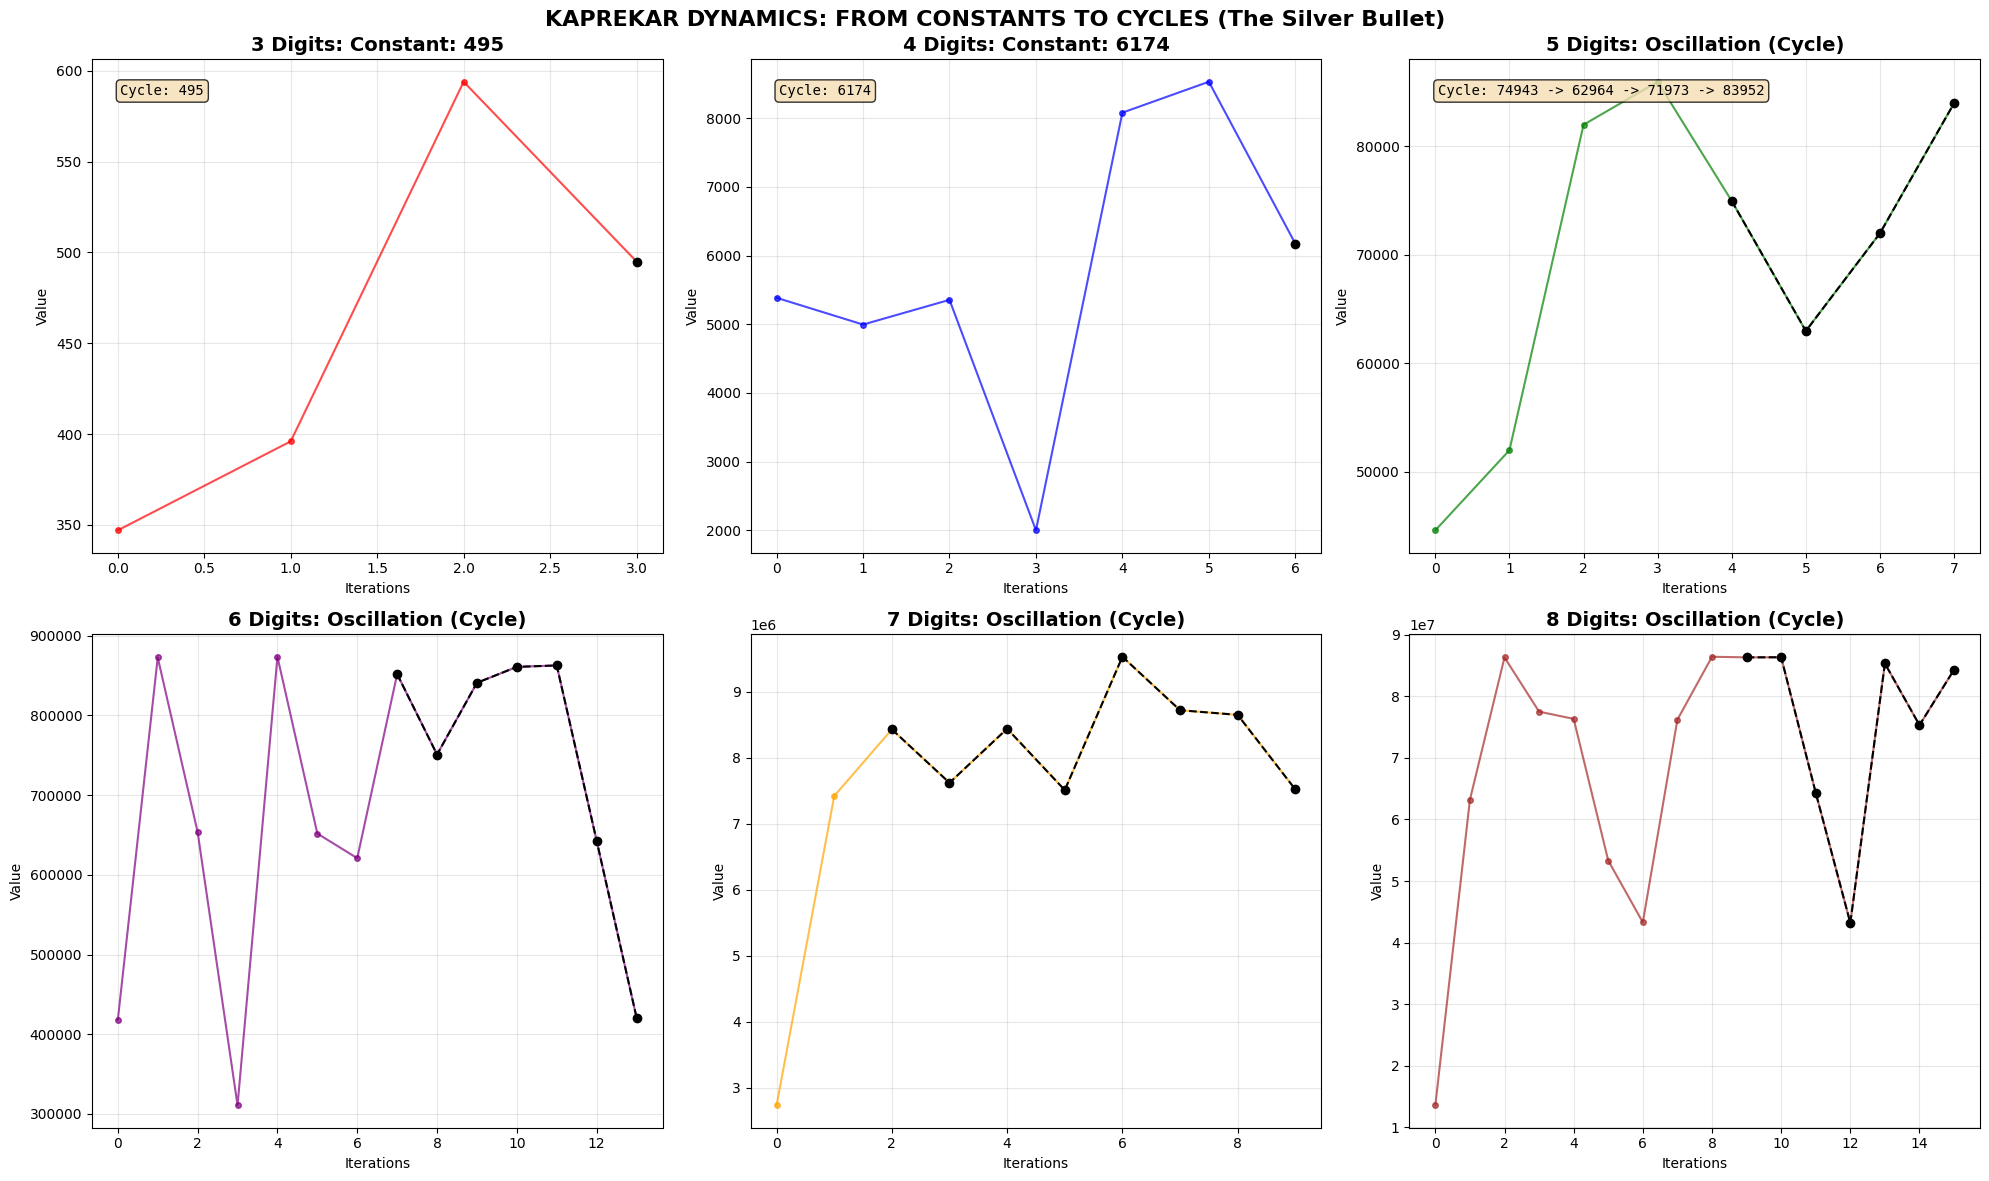


THEORY CONFIRMED
1. 3 & 4 Digits: The system HALTS at a Constant (495, 6174).
2. 5+ Digits: The system enters a LOOP (Cycle).
3. Conclusion: A finite alphabet cannot support infinite, non-repeating behavior.
   It MUST converge or cycle.


In [1]:
"""
kaprekar_silver_bullet.py
==========================
The Silver Bullet: Finite Alphabets Force Cycles.
Demonstrates that for 5+ digits, Kaprekar process never stops, but loops.
This proves "Infinity" is impossible in a finite state system.

Author: Néstor E. Ramos
For: "The Pixelated Universe" - Finite State Necessity
"""

import numpy as np
import matplotlib.pyplot as plt
import random

print("=" * 70)
print("KAPREKAR SILVER BULLET: CYCLES IN FINITE ALPHABETS")
print("=" * 70)

# =============================================================================
# KAPREKAR ENGINE
# =============================================================================

def kaprekar_step(n, num_digits):
    """
    Descending - Ascending.
    Returns the next number in the sequence.
    """
    s = f"{n:0{num_digits}d}"
    # Handle repdigits (e.g., 11111) which go to 0 and stay there
    if len(set(s)) <= 1:
        return 0

    desc = int(''.join(sorted(s, reverse=True)))
    asc = int(''.join(sorted(s)))
    return desc - asc

def find_trajectory(start_n, num_digits):
    """
    Simulate the process until a loop is detected.
    Returns: (path_list, cycle_indices)
    """
    path = [start_n]
    seen = {start_n: 0}

    current = start_n
    step_count = 0

    # Safety break, though mathematically impossible to run forever
    max_steps = 500

    for i in range(1, max_steps + 1):
        next_val = kaprekar_step(current, num_digits)

        if next_val in seen:
            # CYCLE DETECTED!
            start_index = seen[next_val]
            cycle_len = i - start_index
            return path, (start_index, i-1, cycle_len)

        seen[next_val] = i
        path.append(next_val)
        current = next_val

    return path, None

# =============================================================================
# VISUALIZATION
# =============================================================================

def generate_silver_bullet_charts():
    """
    Generate the charts comparing 3, 4 (Fixed) vs 5, 6, 7 (Cycles).
    """
    # We will plot 3, 4, 5, 6, 7, 8 digits
    digits_to_test = [3, 4, 5, 6, 7, 8]

    # Create figure with 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']

    for idx, n_digits in enumerate(digits_to_test):
        ax = axes[idx]

        # Pick a starting number that isn't a repdigit
        # For higher digits, we need to be careful not to pick 11111 etc.
        # We'll try a few times to get a 'good' number (one with varied digits)
        attempts = 0
        start_n = 0
        while attempts < 100:
            start_n = random.randint(10**(n_digits-1), 10**n_digits - 1)
            s = str(start_n)
            if len(set(s)) > 2: # Ensure enough variety to generate a sequence
                break
            attempts += 1

        path, cycle_info = find_trajectory(start_n, n_digits)

        # Plot
        steps = range(len(path))
        ax.plot(steps, path, marker='o', linestyle='-', markersize=4, linewidth=1.5, color=colors[idx], alpha=0.7)

        if cycle_info:
            start_idx, end_idx, length = cycle_info
            # Highlight the cycle
            cycle_x = steps[start_idx:]
            cycle_y = path[start_idx:]
            ax.plot(cycle_x, cycle_y, marker='o', linestyle='--', color='black', linewidth=1.5, label=f'Cycle (Length {length})')

            # Add text description
            if length == 1 and path[-1] == 0:
                title_status = "Trivial Zero"
            elif length == 1:
                title_status = f"Constant: {path[-1]}"
            else:
                title_status = f"Oscillation (Cycle)"

            ax.set_title(f"{n_digits} Digits: {title_status}", fontsize=14, fontweight='bold')

            # Add text box with the cycle values (for small cycles)
            if length <= 5:
                cycle_str = " -> ".join([str(x) for x in cycle_y])
                ax.text(0.05, 0.95, f"Cycle: {cycle_str}", transform=ax.transAxes,
                        fontsize=10, verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        else:
            ax.set_title(f"{n_digits} Digits: No Cycle Found", fontsize=14)

        ax.set_xlabel("Iterations")
        ax.set_ylabel("Value")
        ax.grid(True, alpha=0.3)

        print(f"{n_digits} Digits: Converged to cycle of length {cycle_info[2] if cycle_info else 'Unknown'}")

    plt.suptitle("KAPREKAR DYNAMICS: FROM CONSTANTS TO CYCLES (The Silver Bullet)",
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    fig.savefig("kaprekar_silver_bullet.png", dpi=300, bbox_inches='tight')
    print("\n✓ Saved: kaprekar_silver_bullet.png")
    plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("\nRunning Silver Bullet Simulation...")
    generate_silver_bullet_charts()

    print("\n" + "=" * 70)
    print("THEORY CONFIRMED")
    print("=" * 70)
    print("1. 3 & 4 Digits: The system HALTS at a Constant (495, 6174).")
    print("2. 5+ Digits: The system enters a LOOP (Cycle).")
    print("3. Conclusion: A finite alphabet cannot support infinite, non-repeating behavior.")
    print("   It MUST converge or cycle.")
    print("=" * 70)